# Used Car Price Analysis (CRISP-DM)


## 1. Business Understanding
Objectives: Identify what factors most strongly influence used car prices and provide recommendations to car dealerships.
Plan: Understand data, prepare the data, explore the data, use modeling, evaluate the findings, provide recommendations to the car dealership

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('vehicles.csv')
df.head(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7309268658,asheville,7995,1998.0,bmw,NaN,NaN,NaN,gas,132000.0,clean,manual,NaN,NaN,NaN,NaN,NaN,nc
1,7309264148,asheville,25590,2020.0,buick,encore gx select sport,good,NaN,gas,1113.0,clean,automatic,KL4MMDSL6LB104869,fwd,NaN,SUV,red,nc
2,7309257497,asheville,24995,2013.0,chevrolet,silverado 1500,NaN,8 cylinders,gas,51349.0,clean,other,3GCPKPEAXDG343015,4wd,NaN,truck,silver,nc
3,7309235869,asheville,0,2010.0,mazda,mazda3,NaN,4 cylinders,gas,172513.0,clean,automatic,JM1BL1SF2A1235678,fwd,NaN,sedan,silver,nc
4,7309229267,asheville,7500,2014.0,jeep,patriot,good,4 cylinders,gas,127000.0,clean,manual,NaN,fwd,mid-size,SUV,blue,nc
5,7309223314,asheville,31590,2019.0,cadillac,xt4 sport suv 4d,good,NaN,other,12102.0,clean,other,1GYFZER40KF121673,fwd,NaN,hatchback,black,nc
6,7309222637,asheville,10810,2014.0,mercedes-benz,c-class,NaN,4 cylinders,gas,124476.0,clean,automatic,NaN,rwd,sub-compact,coupe,white,nc
7,7309217935,asheville,6700,2006.0,bmw,x3 3.0i,good,6 cylinders,gas,130000.0,clean,automatic,NaN,4wd,mid-size,SUV,black,nc
8,7309189726,asheville,38999,2020.0,toyota,highlander,NaN,NaN,gas,16467.0,clean,automatic,5TDGZRBHXLS000200,NaN,NaN,NaN,brown,nc
9,7309185126,asheville,0,2013.0,lexus,rx 350,NaN,6 cylinders,gas,58222.0,clean,automatic,2T2BK1BA6DC156274,4wd,mid-size,SUV,custom,nc


## 2. Data Understanding
Preview data columns and type.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196240 entries, 0 to 196239
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            196240 non-null  int64  
 1   region        196240 non-null  object 
 2   price         196240 non-null  int64  
 3   year          195891 non-null  float64
 4   manufacturer  188466 non-null  object 
 5   model         193692 non-null  object 
 6   condition     114820 non-null  object 
 7   cylinders     114537 non-null  object 
 8   fuel          194314 non-null  object 
 9   odometer      194104 non-null  float64
 10  title_status  192765 non-null  object 
 11  transmission  194787 non-null  object 
 12  VIN           122753 non-null  object 
 13  drive         137322 non-null  object 
 14  size          56112 non-null   object 
 15  type          154946 non-null  object 
 16  paint_color   136666 non-null  object 
 17  state         196240 non-null  object 
dtypes: f

In [6]:
df['price'].describe()

count    1.962400e+05
mean     7.476015e+04
std      1.376033e+07
min      0.000000e+00
25%      5.499000e+03
50%      1.350000e+04
75%      2.659000e+04
max      3.736929e+09
Name: price, dtype: float64

## 3. Data Preparation
Preparting the dataset to only keep rows with Price>0 or empty.
Convert the price and odometer to Log as the price range and odometer range is abnormally high based on .describe()
Calculate Age from 2025 to analyze the impact of Age of the car.

In [9]:
# Clean price and Odometer
df = df[df['price'].notnull() & (df['price'] > 0)]
df = df[df['odometer'].notnull() & (df['odometer'] > 0)]

# Feature engineering
df['age'] = 2025 - df['year']
df['log_price'] = np.log(df['price'])
df['log_odometer'] = np.log(df['odometer'])
df[['age','odometer','log_price', 'log_odometer']].head()

,age,odometer,log_price,log_odometer
0,27.0,132000.0,8.986572,11.790557
1,5.0,1113.0,10.149957,7.014814
2,12.0,51349.0,10.126431,10.846401
4,11.0,127000.0,8.922658,11.751942
5,6.0,12102.0,10.360596,9.401126


## 4. Exploratory Data Analysis

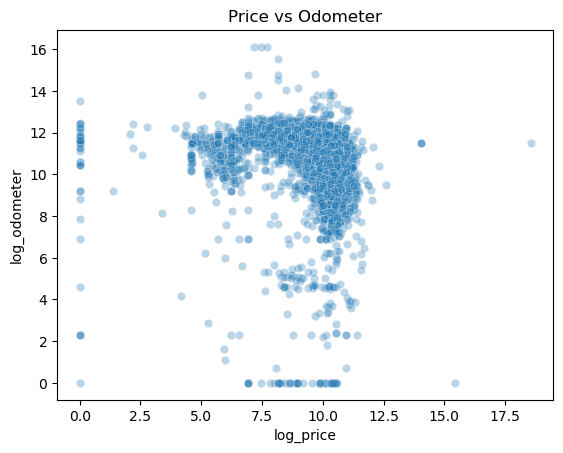

In [12]:
sns.scatterplot(data=df.sample(10000), x='log_price', y='log_odometer', alpha=0.3)
plt.title('Price vs Odometer')
plt.show()

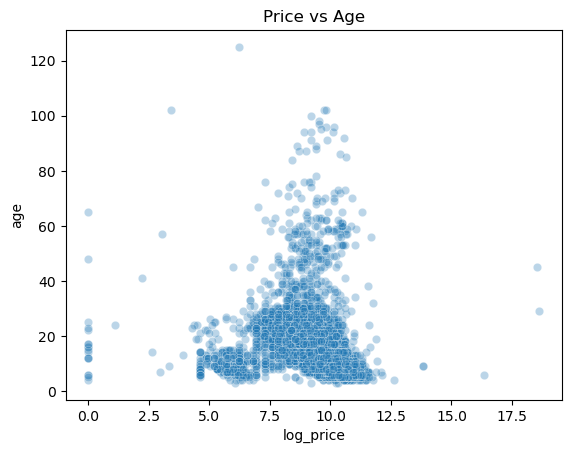

In [14]:
sns.scatterplot(data=df.sample(10000), x='log_price', y='age', alpha=0.3)
plt.title('Price vs Age')
plt.show()

### Correlation

In [17]:
df[['age','log_odometer','log_price']].corr()

,age,log_odometer,log_price
age,1.000000,0.156870,-0.294364
log_odometer,0.156870,1.000000,-0.210588
log_price,-0.294364,-0.210588,1.000000


## 5. Modeling (Linear Regression)
Perform Linear Regression on age and odometer.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['age','log_odometer']].fillna(df[['age','log_odometer']].median())
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
r2_score(y_test, pred)

0.12124736026010152

## 6. Evaluation of the observations
- Age- Strongly impact the price. Newer cars are sold at higher price.
- Odometer - Higher Mileage = Lower Price
- Opportunity to look into categorical variables to make the model even more effecient.


## 7. Deployment / Recommendation
- Look for Low-age and Low-Mileage Car in the inventory which should provide better price.
- There could be other categorical variables impact such as manufacturers or title status which may impact the price of the used car.